In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from astropy import units as u
import itertools
import pandas as pd

In [3]:
stem = '/Users/eckhartspalding/Documents/git.repos/nice/data/'

In [4]:
trans_ne13a = pd.read_csv(stem + 'trans_thorlabs_ne13a.csv', sep='\s+')
trans_ne20a = pd.read_csv(stem + 'trans_thorlabs_ne20a.csv', sep='\s+')
trans_ne30a = pd.read_csv(stem + 'trans_thorlabs_ne30a.csv', sep='\s+')
trans_ndir30a = pd.read_csv(stem + 'trans_thorlabs_ndir30a.csv', sep='\s+')
trans_ndirw30b = pd.read_csv(stem + 'trans_thorlabs_ndirw30b.csv', sep='\s+')


In [5]:
# make columns in units of interest
trans_ne13a['wavel_um'] = 1e-3 * trans_ne13a['wavel_nm']
trans_ne13a['trans'] = 1e-2 * trans_ne13a['percent_transmission']
trans_ne20a['wavel_um'] = 1e-3 * trans_ne20a['wavel_nm']
trans_ne20a['trans'] = 1e-2 * trans_ne20a['percent_transmission']
trans_ne30a['wavel_um'] = 1e-3 * trans_ne30a['wavel_nm']
trans_ne30a['trans'] = 1e-2 * trans_ne30a['percent_transmission']
trans_ndir30a['wavel_um'] = 1e-3 * trans_ndir30a['wavel_nm']
trans_ndir30a['trans'] = 1e-2 * trans_ndir30a['percent_transmission']
trans_ndirw30b['wavel_um'] = 1e-3 * trans_ndirw30b['wavel_nm']
trans_ndirw30b['trans'] = 1e-2 * trans_ndirw30b['percent_transmission']


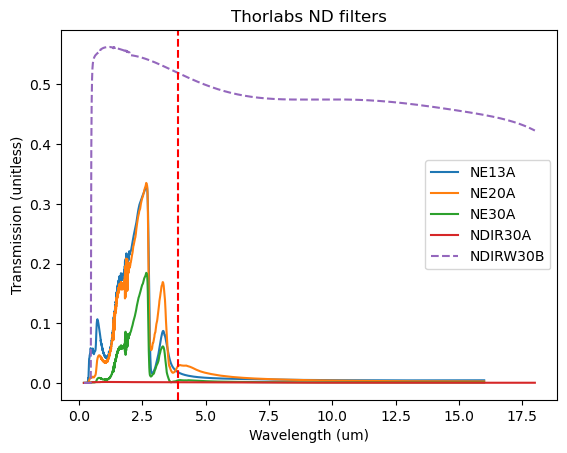

In [6]:
plt.plot(trans_ne13a['wavel_um'], trans_ne13a['trans'], label='NE13A')
plt.plot(trans_ne20a['wavel_um'], trans_ne20a['trans'], label='NE20A')
plt.plot(trans_ne30a['wavel_um'], trans_ne30a['trans'], label='NE30A')
plt.plot(trans_ndir30a['wavel_um'], trans_ndir30a['trans'], label='NDIR30A')
plt.plot(trans_ndirw30b['wavel_um'], trans_ndirw30b['trans'], label='NDIRW30B', linestyle='--')
plt.axvline(x=3.9, color='r', linestyle='--')
plt.legend()
plt.xlabel('Wavelength (um)')
plt.ylabel('Transmission (unitless)')
plt.title('Thorlabs ND filters')
plt.show()


In [7]:
# interpolate the trans_ne13a['percent_transmission'] for the value at a wavelength of N um
def interp_trans(target_um, trans_df):
    # Interpolate percent_transmission at the target wavelength (um), converting nm to um
    interp_trans = np.interp(target_um, trans_df['wavel_um'], trans_df['trans'])
    return interp_trans


In [8]:
# Interpolate percent_transmission at the target wavelength (um), converting nm to um
target_um = 3.9 # wavelength of interest
trans_laser_ne13a = np.interp(target_um, trans_ne13a['wavel_um'], trans_ne13a['trans'])
trans_laser_ne20a = np.interp(target_um, trans_ne20a['wavel_um'], trans_ne20a['trans'])
trans_laser_ne30a = np.interp(target_um, trans_ne30a['wavel_um'], trans_ne30a['trans'])
trans_laser_ndir30a = np.interp(target_um, trans_ndir30a['wavel_um'], trans_ndir30a['trans'])
trans_laser_ndirw30b = np.interp(target_um, trans_ndirw30b['wavel_um'], trans_ndirw30b['trans'])

print(trans_laser_ne13a)
print(trans_laser_ne20a)
print(trans_laser_ne30a)
print(trans_laser_ndir30a)
print(trans_laser_ndirw30b)

0.018351551838429826
0.027553938772250337
0.0041609707748060725
0.0010098448867806227
0.5194464285647714


In [9]:
# equivalent NDs

ND_ne13a = - np.log10(trans_laser_ne13a)
ND_ne20a = - np.log10(trans_laser_ne20a)
ND_ne30a = - np.log10(trans_laser_ne30a)
ND_ndir30a = - np.log10(trans_laser_ndir30a)
ND_ndirw30b = - np.log10(trans_laser_ndirw30b)

In [10]:
print(ND_ne13a)
print(ND_ne20a)
print(ND_ne30a)
print(ND_ndir30a)
print(ND_ndirw30b)

1.7363272051791567
1.5598163109760537
2.3808053345278957
2.9957453291764007
0.2844592353606763


In [11]:
dict_NDs = {'NE13A': ND_ne13a, 'NE20A': ND_ne20a, 'NE30A': ND_ne30a, 'NDIR30A': ND_ndir30a, 'NDIRW30B': ND_ndirw30b}
dict_NDs_no_ND_ndirw30b = {'NE13A': ND_ne13a, 'NE20A': ND_ne20a, 'NE30A': ND_ne30a, 'NDIR30A': ND_ndir30a}

In [12]:
# net ND of all possible filter permutations

# define list of filter names
filter_names = list(dict_NDs_no_ND_ndirw30b.keys())
# Will store combinations and their summed NDs
combos_nds = []
sum_NDs = []

# For each possible number of filters (1 up to all filters)
for r in range(1, len(filter_names) + 1):
    for combo in itertools.combinations(filter_names, r):
        combo_sum = sum([dict_NDs[f] for f in combo])
        combos_nds.append(' + '.join(combo))
        sum_NDs.append(combo_sum)

# Create a pandas DataFrame for clearer display
combos_nds_df = pd.DataFrame({'Filters': combos_nds, 'Total_ND': sum_NDs})

combos_nds_df.sort_values(by='Total_ND', ascending=False, inplace=True)

In [13]:
# include effect of power levels

power_levels = np.array([1.5, 7.5, 15.0, 75.0, 150.0, 183.0]) * u.mW # set by laser

# Create a list to store the expanded rows
expanded_rows = []

# Enumerate every row in combos_nds_df with each power level
for idx, row in combos_nds_df.iterrows():
    for power in power_levels:
        expanded_rows.append({
            'Filters': row['Filters'],
            'Total_ND': row['Total_ND'],
            'Power_mW_emitted': power.value  # store as float for easy analysis
        })

# Create the expanded dataframe
combos_power_df = pd.DataFrame(expanded_rows)

# add column of received power at the detector
combos_power_df['Power_mW_received'] = combos_power_df['Power_mW_emitted'] * 10**(-combos_power_df['Total_ND'])


combos_power_df.sort_values(by='Power_mW_received', ascending=True, inplace=True)

In [14]:
pd.set_option('display.max_rows', 500)
print(combos_power_df[['Filters', 'Power_mW_emitted', 'Power_mW_received']])

                            Filters  Power_mW_emitted  Power_mW_received
0   NE13A + NE20A + NE30A + NDIR30A               1.5       3.187110e-09
1   NE13A + NE20A + NE30A + NDIR30A               7.5       1.593555e-08
2   NE13A + NE20A + NE30A + NDIR30A              15.0       3.187110e-08
6           NE13A + NE30A + NDIR30A               1.5       1.156680e-07
3   NE13A + NE20A + NE30A + NDIR30A              75.0       1.593555e-07
12          NE20A + NE30A + NDIR30A               1.5       1.736698e-07
4   NE13A + NE20A + NE30A + NDIR30A             150.0       3.187110e-07
5   NE13A + NE20A + NE30A + NDIR30A             183.0       3.888274e-07
7           NE13A + NE30A + NDIR30A               7.5       5.783402e-07
18          NE13A + NE20A + NDIR30A               1.5       7.659535e-07
13          NE20A + NE30A + NDIR30A               7.5       8.683490e-07
8           NE13A + NE30A + NDIR30A              15.0       1.156680e-06
14          NE20A + NE30A + NDIR30A              15

In [ ]:
# Note 185 uW led to ~50% max ADU on the detector; so the incident power could be as high as ~260 uW (~70% of max well)

power_lower_limit = 7.5e-3 * u.mW
power_upper_safe_limit = 260e-3 * u.mW
combos_power_df_useable_range = combos_power_df[
    (combos_power_df['Power_mW_received'] > (power_lower_limit)) &
    (combos_power_df['Power_mW_received'] < (power_upper_safe_limit
))
]

In [28]:
# possible combinations of filters-ND
combos_nds_df

,Filters,Total_ND
14,NE13A + NE20A + NE30A + NDIR30A,8.672694
12,NE13A + NE30A + NDIR30A,7.112878
13,NE20A + NE30A + NDIR30A,6.936367
11,NE13A + NE20A + NDIR30A,6.291889
10,NE13A + NE20A + NE30A,5.676949
9,NE30A + NDIR30A,5.376551
6,NE13A + NDIR30A,4.732073
8,NE20A + NDIR30A,4.555562
5,NE13A + NE30A,4.117133
7,NE20A + NE30A,3.940622


In [29]:
# useable combinations (modulo ones where the total ND is so high that signal is lost in noise)
print(len(combos_nds_df[combos_nds_df['Total_ND'] > 2.9]))

12


In [30]:
# possible combinations of filters based on incident power

combos_power_df_useable_range

,Filters,Total_ND,Power_mW_emitted,Power_mW_received
67,NDIR30A,2.995745,7.5,0.007574
62,NE13A + NE20A,3.296144,15.0,0.007585
57,NE20A + NE30A,3.940622,75.0,0.008599
52,NE13A + NE30A,4.117133,150.0,0.011454
53,NE13A + NE30A,4.117133,183.0,0.013974
68,NDIR30A,2.995745,15.0,0.015148
58,NE20A + NE30A,3.940622,150.0,0.017198
59,NE20A + NE30A,3.940622,183.0,0.020981
78,NE13A,1.736327,1.5,0.027527
73,NE30A,2.380805,7.5,0.031207


In [31]:
len(combos_power_df_useable_range)

20